An advertising agency works with a brand called SmartAD to develop interactive ads. This new advertisement is expected to attract a large number of users to fill out their questionnaires. To determine whether the interactive ads generated more responses to their questionnaire, they conducted an A/B test. Some users are shown new ads and others are shown dummy ads. This project will help companies interpret the results of A/B testing.

In [81]:
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

In [2]:
file_path = 'data/AdSmartABdata - AdSmartABdata.csv'
if not os.path.exists(file_path):
    import kagglehub
    kagglehub.dataset_download("osuolaleemmanuel/ad-ab-testing", output_dir='data', force_download=True)

df = pd.read_csv(file_path)
df.head()

,auction_id,experiment,date,hour,device_make,platform_os,browser,yes,no
0,0008ef63-77a7-448b-bd1e-075f42c55e39,exposed,2020-07-10,8,Generic Smartphone,6,Chrome Mobile,0,0
1,000eabc5-17ce-4137-8efe-44734d914446,exposed,2020-07-07,10,Generic Smartphone,6,Chrome Mobile,0,0
2,0016d14a-ae18-4a02-a204-6ba53b52f2ed,exposed,2020-07-05,2,E5823,6,Chrome Mobile WebView,0,1
3,00187412-2932-4542-a8ef-3633901c98d9,control,2020-07-03,15,Samsung SM-A705FN,6,Facebook,0,0
4,001a7785-d3fe-4e11-a344-c8735acacc2c,control,2020-07-03,15,Generic Smartphone,6,Chrome Mobile,0,0


In [24]:
len(df[(df['yes'] == 0 ) & (df['no'] == 0)])/len(df)

0.8461062275597375

In [79]:
responsive_df = df[(df['yes'] == 1 )| (df['no'] == 1)].reset_index(drop=True)
responsive_df

,auction_id,experiment,date,hour,device_make,platform_os,browser,yes,no
0,0016d14a-ae18-4a02-a204-6ba53b52f2ed,exposed,2020-07-05,2,E5823,6,Chrome Mobile WebView,0,1
1,008aafdf-deef-4482-8fec-d98e3da054da,exposed,2020-07-04,16,Generic Smartphone,6,Chrome Mobile,1,0
2,00a1384a-5118-4d1b-925b-6cdada50318d,exposed,2020-07-06,8,Generic Smartphone,6,Chrome Mobile,0,1
3,00b6fadb-10bd-49e3-a778-290da82f7a8d,control,2020-07-08,4,Samsung SM-A202F,6,Facebook,1,0
4,00ebf4a8-060f-4b99-93ac-c62724399483,control,2020-07-03,15,Generic Smartphone,6,Chrome Mobile,0,1
...,...,...,...,...,...,...,...,...,...
1238,ffa08ff9-a132-4051-aef5-01a9c79367bc,exposed,2020-07-05,21,Generic Smartphone,6,Chrome Mobile,1,0
1239,ffb176df-ecd2-45d3-b05f-05b173a093a7,exposed,2020-07-04,1,Generic Smartphone,6,Chrome Mobile,1,0
1240,ffb79718-6f25-4896-b6b3-e58b80a6e147,control,2020-07-09,7,Generic Smartphone,6,Chrome Mobile,0,1
1241,ffca1153-c182-4f32-9e90-2a6008417497,control,2020-07-10,16,Generic Smartphone,6,Chrome Mobile,0,1


### Sample Ratio Mismatch

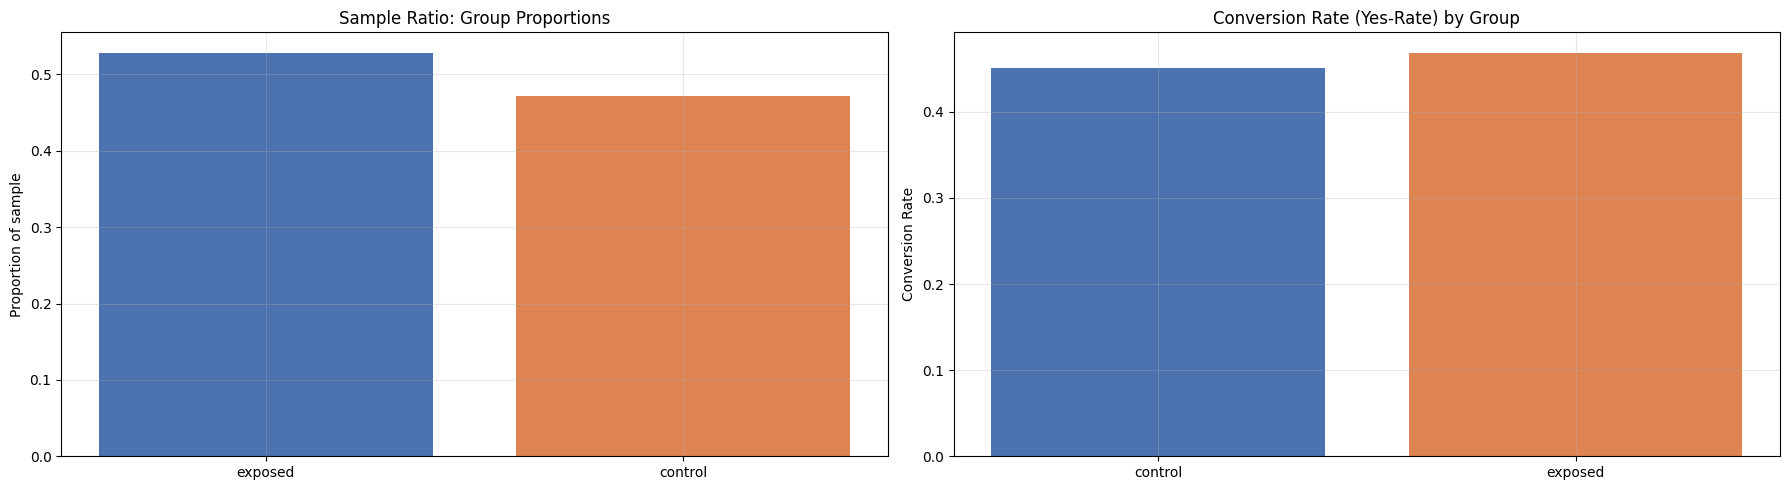

Reject H0 : SRM probably exist
Chi-square statistic: 0.3465
A/B test p-value: 0.5561
Failed to reject H0: No significant difference in conversion rate


In [121]:
group_proportions  = responsive_df['experiment'].value_counts(normalize=True)
fig, axes = plt.subplots(1,2,figsize=(18,5))
axes[0].bar(group_proportions.index,group_proportions.values,color= ['#4C72B0', '#DD8452'])
axes[0].set_title("Sample Ratio: Group Proportions")
axes[0].set_ylabel("Proportion of sample")
axes[0].grid(alpha=0.3)

conversion_rate = responsive_df.groupby('experiment')['yes'].mean()
axes[1].bar(conversion_rate.index, conversion_rate.values, color=['#4C72B0', '#DD8452'])
axes[1].set_title("Conversion Rate (Yes-Rate) by Group")
axes[1].set_ylabel("Conversion Rate")
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

group_counts = responsive_df['experiment'].value_counts()
chi2_stat, p_value_srm = chisquare(group_counts)
if p_value_srm<0.05:
     print("Reject H0 : SRM probably exist")
else:
     print("Failed to reject H0 : No SRM")

contingency = pd.crosstab(responsive_df['experiment'], responsive_df['yes'])
chi2, p_value_ab, dof, expected = chi2_contingency(contingency)
print(f"Chi-square statistic: {chi2:.4f}")
print(f"A/B test p-value: {p_value_ab:.4f}")

if p_value_ab < 0.05:
     print(f"The new ad format significantly increases conversion rate")
else:
    print("Failed to reject H0: No significant difference in conversion rate")